# 🍷 Classificando a Qualidade de Vinhos com Machine Learning
### Tech Challenge — Fase 2 | Data Analytics

**Grupo:**

- **Emerson Henrique de Lima e Sousa** — RM 373751
- **Moacyr Souza Barros** — RM 373412

**Dataset:** Wine Quality Dataset (Kaggle — yasserh/wine-quality-dataset)

---

## 1. Compreensão do Problema

A avaliação da qualidade de um vinho é tradicionalmente feita por especialistas através de análise sensorial (aroma, sabor, acidez, equilíbrio). Esse processo é subjetivo, caro e não escala.

Este projeto usa **variáveis físico-químicas** medidas em laboratório (acidez, teor alcoólico, densidade, dióxido de enxofre etc.) para **prever se um vinho é de Alta Qualidade ou não**, apoiando enólogos e produtores na padronização da qualidade.

**Variável alvo:** `quality`, transformada em problema de **classificação binária**:
- `1` → Alta Qualidade (nota ≥ 7)
- `0` → Baixa/Média Qualidade (nota < 7)

**Dataset:** amostra de **1.143 vinhos tintos** portugueses ("Vinho Verde"), com 11 variáveis físico-químicas + a nota de qualidade atribuída por especialistas (escala 0–10).


## 2. Setup e Importação das Bibliotecas

In [ ]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento e pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier 
from sklearn.tree import DecisionTreeClassifier

# Métricas
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                              roc_curve, roc_auc_score, RocCurveDisplay, f1_score,
                              precision_score, recall_score, accuracy_score)

import warnings
warnings.filterwarnings('ignore')

# Configuração visual
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (9, 5)
RANDOM_STATE = 42

import os
os.makedirs('../results', exist_ok=True)


## 3. Carregando os Dados

> **No Google Colab:** faça upload do arquivo `WineQT.csv` (via `files.upload()`) ou monte o Google Drive.
> Aqui assumimos que o arquivo está na pasta `data/` do repositório (estrutura recomendada).

In [ ]:
# Se estiver rodando no Colab e quiser fazer upload manual, descomente:
# from google.colab import files
# uploaded = files.upload()

df = pd.read_csv('../data/WineQT.csv')

# A coluna 'Id' é apenas um identificador de linha, não é uma feature físico-química
df.drop(columns=['Id'], inplace=True, errors='ignore')

print(f'Dimensões do dataset: {df.shape[0]} linhas x {df.shape[1]} colunas')
df.head()


Dimensões do dataset: 1143 linhas x 12 colunas


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 107.3 KB


In [ ]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0,8.311111,1.747595,4.60000,7.10000,7.90000,9.100000,15.90000
volatile acidity,1143.0,0.531339,0.179633,0.12000,0.39250,0.52000,0.640000,1.58000
citric acid,1143.0,0.268364,0.196686,0.00000,0.09000,0.25000,0.420000,1.00000
residual sugar,1143.0,2.532152,1.355917,0.90000,1.90000,2.20000,2.600000,15.50000
chlorides,1143.0,0.086933,0.047267,0.01200,0.07000,0.07900,0.090000,0.61100
free sulfur dioxide,1143.0,15.615486,10.250486,1.00000,7.00000,13.00000,21.000000,68.00000
total sulfur dioxide,1143.0,45.914698,32.782130,6.00000,21.00000,37.00000,61.000000,289.00000
density,1143.0,0.996730,0.001925,0.99007,0.99557,0.99668,0.997845,1.00369
pH,1143.0,3.311015,0.156664,2.74000,3.20500,3.31000,3.400000,4.01000
sulphates,1143.0,0.657708,0.170399,0.33000,0.55000,0.62000,0.730000,2.00000


### 3.1 Auditoria de Qualidade dos Dados

Antes de qualquer análise, criamos uma função reutilizável de auditoria de qualidade — o mesmo tipo de checagem que aplicaríamos em qualquer novo dataset do projeto (tipo de dado, nulos, valores únicos e duplicidade), consolidada em uma única tabela em vez de comandos soltos.

In [ ]:
def qualidade_dados(df: pd.DataFrame, nome: str) -> pd.DataFrame:
    """
    Gera uma tabela de auditoria de qualidade para um DataFrame.

    Para cada coluna, resume: tipo de dado, quantidade e percentual de valores nulos,
    e quantidade de valores únicos. Também reporta o total de linhas duplicadas na base.
    Função reutilizável para qualquer dataset do projeto (ex.: em uma futura combinação
    com a base de vinho branco, ou em outra fonte de dados).

    Parâmetros
    ----------
    df : pd.DataFrame
        Base de dados a ser auditada.
    nome : str
        Nome identificador da base (aparece na coluna 'base' do resumo).

    Retorna
    -------
    pd.DataFrame
        Uma linha por coluna de `df`, com as métricas de qualidade.
    """
    resumo = pd.DataFrame({
        'base': nome,
        'coluna': df.columns,
        'tipo': df.dtypes.astype(str).values,
        'qtd_nulos': df.isnull().sum().values,
        'pct_nulos': (df.isnull().mean().values * 100).round(2),
        'qtd_unicos': df.nunique().values,
    })
    return resumo


qualidade_wine = qualidade_dados(df, 'WineQT')
print(f'Total de linhas duplicadas na base: {df.duplicated().sum()}')
qualidade_wine

Total de linhas duplicadas na base: 125


,base,coluna,tipo,qtd_nulos,pct_nulos,qtd_unicos
0,WineQT,fixed acidity,float64,0,0.0,91
1,WineQT,volatile acidity,float64,0,0.0,135
2,WineQT,citric acid,float64,0,0.0,77
3,WineQT,residual sugar,float64,0,0.0,80
4,WineQT,chlorides,float64,0,0.0,131
5,WineQT,free sulfur dioxide,float64,0,0.0,53
6,WineQT,total sulfur dioxide,float64,0,0.0,138
7,WineQT,density,float64,0,0.0,388
8,WineQT,pH,float64,0,0.0,87
9,WineQT,sulphates,float64,0,0.0,89


**Observações:**
- O dataset não possui valores nulos em nenhuma coluna (`qtd_nulos` = 0 em toda a tabela de auditoria acima).
- Existem linhas duplicadas — isso é esperado nesse tipo de dado físico-químico (dois vinhos diferentes podem ter medições idênticas arredondadas) e **não vamos removê-las**, pois não há garantia de que sejam erros de coleta, e sim coincidências físico-químicas legítimas.
- A coluna `quality` tem poucos valores únicos (escala discreta de notas), o que já era esperado — é justamente essa variável que será transformada em classificação binária na próxima seção.

## 4. Transformação da Variável Alvo (Classificação Binária)

Conforme o desafio, transformamos `quality` em uma variável binária `high_quality`:
- `quality >= 7` → **1 (Alta Qualidade)**
- `quality < 7`  → **0 (Baixa/Média Qualidade)**

In [ ]:
df['high_quality'] = (df['quality'] >= 7).astype(int)

print('Distribuição original de quality:')
print(df['quality'].value_counts().sort_index())

print('\nDistribuição binária (target):')
print(df['high_quality'].value_counts())
print(df['high_quality'].value_counts(normalize=True).round(3) * 100, '%')


Distribuição original de quality:
quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64

Distribuição binária (target):
high_quality
0    984
1    159
Name: count, dtype: int64
high_quality
0    86.1
1    13.9
Name: proportion, dtype: float64 %


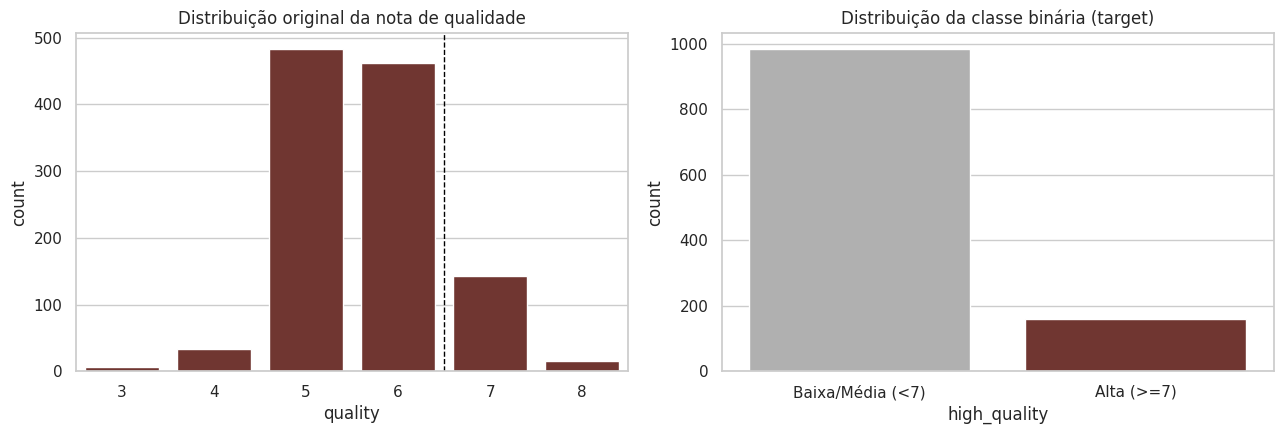

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.countplot(x='quality', data=df, ax=axes[0], color='#7B2D26')
axes[0].set_title('Distribuição original da nota de qualidade')
axes[0].axvline(x=3.5, color='black', linestyle='--', linewidth=1)

sns.countplot(x='high_quality', data=df, ax=axes[1], palette=['#B0B0B0', '#7B2D26'])
axes[1].set_xticklabels(['Baixa/Média (<7)', 'Alta (>=7)'])
axes[1].set_title('Distribuição da classe binária (target)')

plt.tight_layout()
plt.savefig('../results/01_distribuicao_target.png', dpi=150)
plt.show()


⚠️ **Classes desbalanceadas:** apenas ~14% dos vinhos são classificados como "Alta Qualidade". Isso terá impacto direto na escolha de métricas (accuracy sozinha é enganosa) e na estratégia de treino (usaremos `class_weight='balanced'`, `stratify` no split e cross-validation estratificada).

## 5. Análise Exploratória de Dados (EDA)

### 5.1 Distribuição das variáveis numéricas

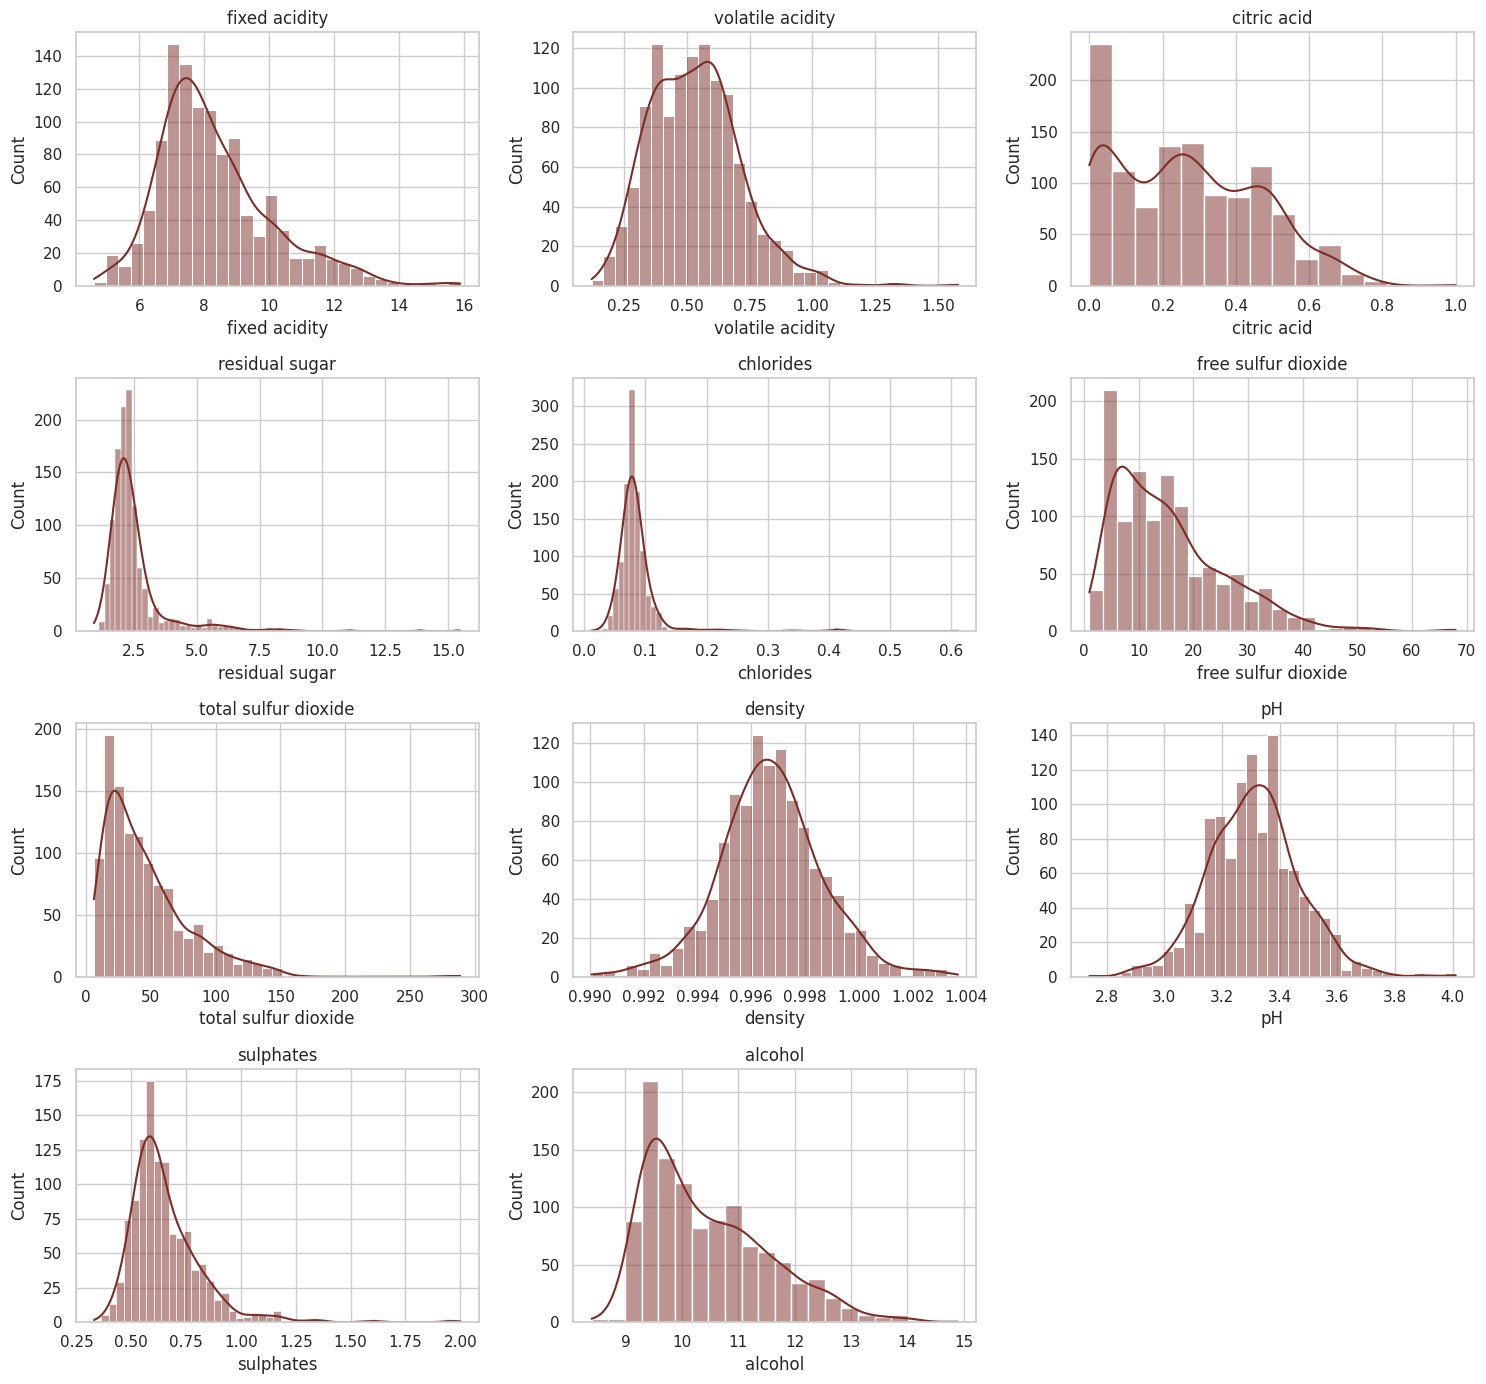

In [ ]:
features = [c for c in df.columns if c not in ['quality', 'high_quality']]

fig, axes = plt.subplots(4, 3, figsize=(15, 14))
axes = axes.flatten()
for i, col in enumerate(features):
    sns.histplot(df[col], kde=True, ax=axes[i], color='#7B2D26')
    axes[i].set_title(col)
for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.savefig('../results/02_distribuicoes_features.png', dpi=150)
plt.show()


**Leitura:**
- `fixed acidity`, `volatile acidity`, `sulphates` e `alcohol` apresentam assimetria à direita (cauda longa), sugerindo presença de outliers.
- `density` e `pH` têm distribuição próxima da normal.
- `residual sugar` e `chlorides` têm forte concentração em valores baixos com poucos outliers extremos.

### 5.2 Relação de cada variável com a qualidade (boxplots)

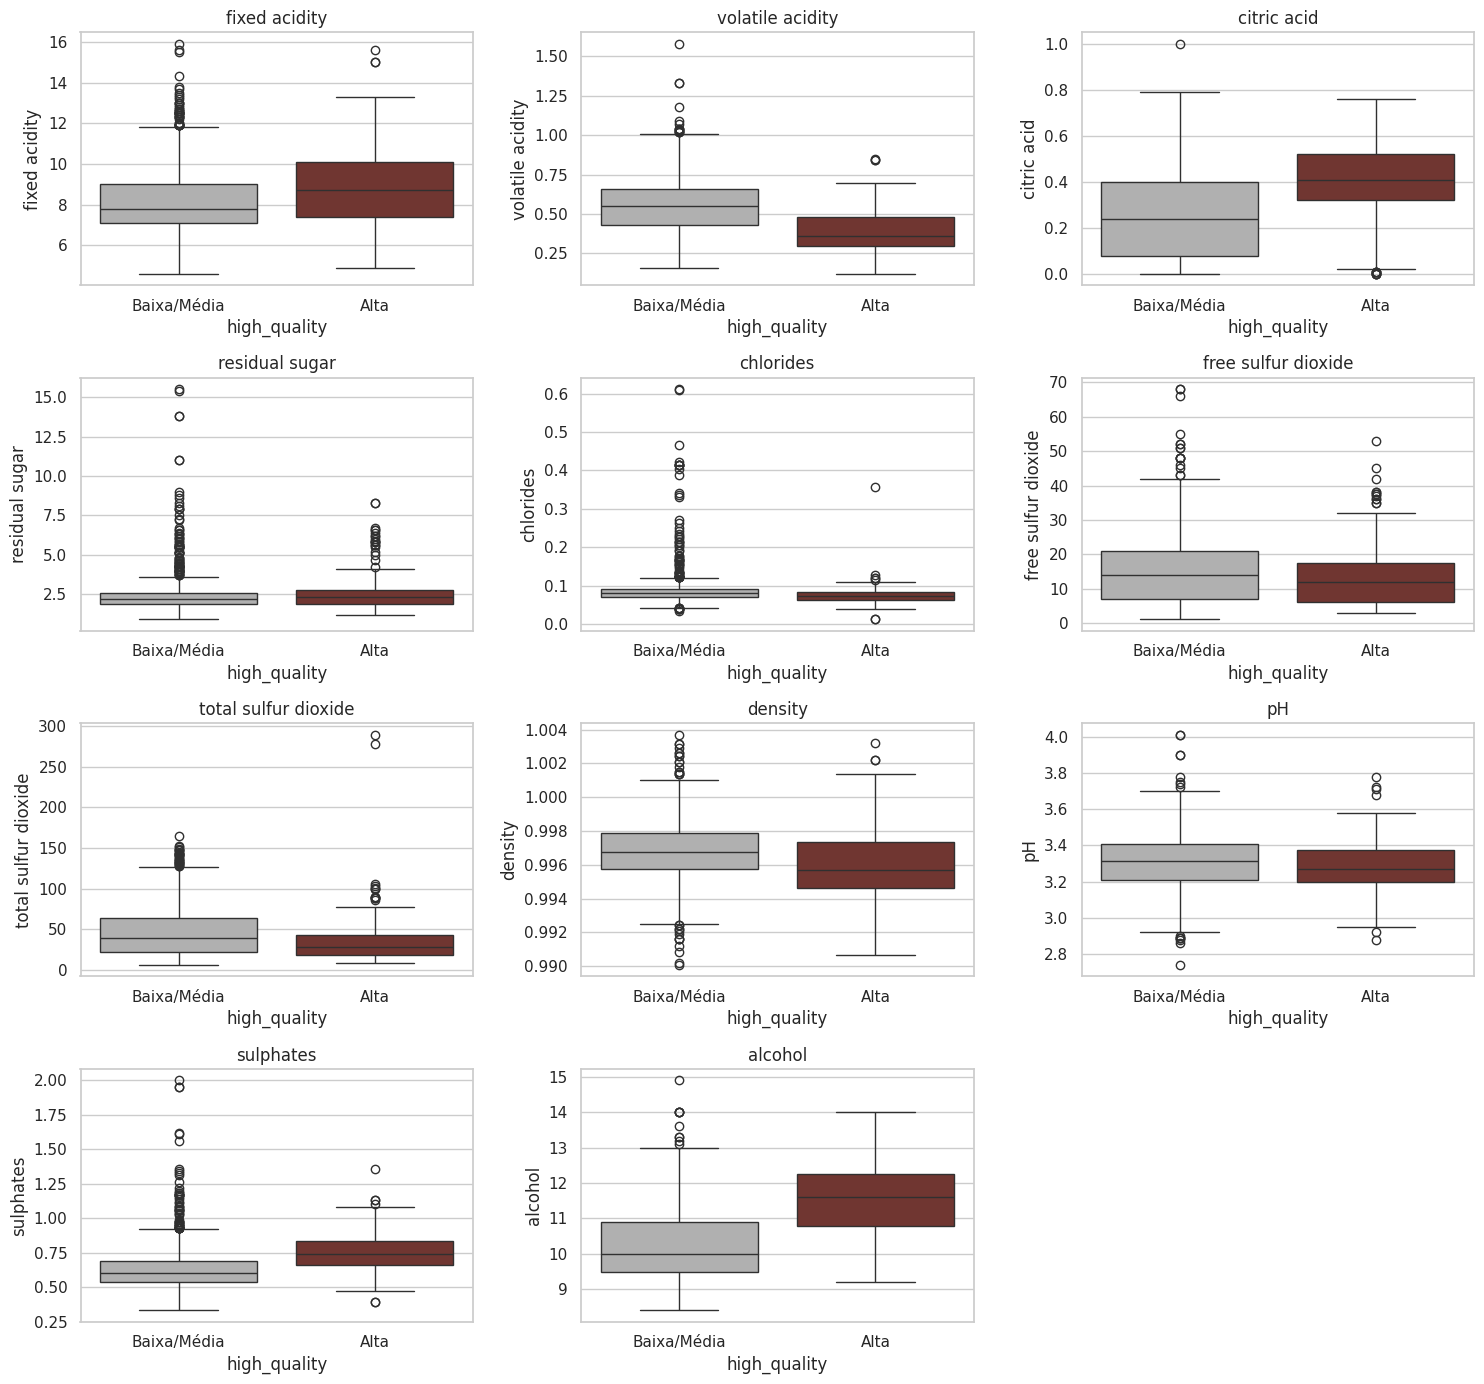

In [ ]:
fig, axes = plt.subplots(4, 3, figsize=(15, 14))
axes = axes.flatten()
for i, col in enumerate(features):
    sns.boxplot(x='high_quality', y=col, data=df, ax=axes[i], palette=['#B0B0B0', '#7B2D26'])
    axes[i].set_title(col)
    axes[i].set_xticklabels(['Baixa/Média', 'Alta'])
for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.savefig('../results/03_boxplots_por_classe.png', dpi=150)
plt.show()


**Leitura:** vinhos de alta qualidade tendem a apresentar `alcohol` mais elevado, `volatile acidity` mais baixa e `sulphates` mais altos — um primeiro indício visual de quais variáveis podem ser mais discriminativas (confirmaremos com correlação e, depois, com a importância de variáveis dos modelos).

### 5.3 Matriz de correlação

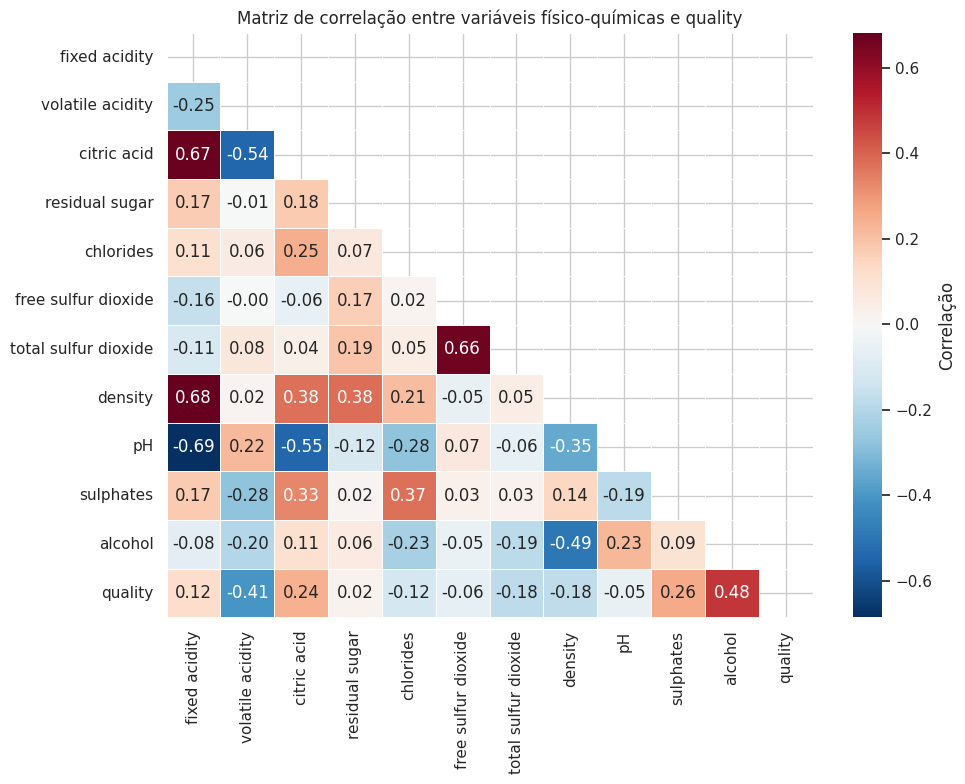

In [ ]:
corr = df[features + ['quality']].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, cbar_kws={'label': 'Correlação'})
plt.title('Matriz de correlação entre variáveis físico-químicas e quality')
plt.tight_layout()
plt.savefig('../results/04_matriz_correlacao.png', dpi=150)
plt.show()


In [ ]:
corr_target = corr['quality'].drop('quality').sort_values(key=abs, ascending=False)
print('Correlação de cada variável com quality (ordenado por força):')
print(corr_target.round(3))


Correlação de cada variável com quality (ordenado por força):
alcohol                 0.485
volatile acidity       -0.407
sulphates               0.258
citric acid             0.241
total sulfur dioxide   -0.183
density                -0.175
chlorides              -0.124
fixed acidity           0.122
free sulfur dioxide    -0.063
pH                     -0.052
residual sugar          0.022
Name: quality, dtype: float64


**Justificativa das correlações mais relevantes:**
- **`alcohol` (positiva, a mais forte):** vinhos com maior teor alcoólico tendem a ter notas mais altas — geralmente associado a uvas mais maduras e fermentação mais completa.
- **`volatile acidity` (negativa):** acidez volátil elevada indica presença de ácido acético (defeito sensorial de "vinagre"), o que reduz a qualidade percebida.
- **`sulphates` (positiva):** atuam como conservante/antioxidante; níveis adequados estão associados a vinhos mais estáveis e de melhor avaliação.
- **`citric acid` (positiva, moderada):** contribui com frescor e equilíbrio de sabor.
- **`density` e `fixed acidity`** têm correlação forte entre si (multicolinearidade esperada, pois densidade é influenciada pelo teor de açúcar/álcool/acidez), mas correlação fraca direta com `quality`.
- **`free sulfur dioxide` e `total sulfur dioxide`** são naturalmente correlacionadas (uma é subconjunto da outra), e ambas têm relação fraca/não-linear com qualidade — por isso vamos testar uma feature derivada (razão entre elas) na etapa de feature engineering.

### 5.4 Detecção de outliers (método IQR)

In [ ]:
outlier_summary = []
for col in features:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({'feature': col, 'n_outliers': n_out,
                             'pct_outliers': round(100 * n_out / len(df), 2)})

outlier_df = pd.DataFrame(outlier_summary).sort_values('pct_outliers', ascending=False)
outlier_df


,feature,n_outliers,pct_outliers
3,residual sugar,110,9.62
4,chlorides,77,6.74
0,fixed acidity,44,3.85
9,sulphates,43,3.76
6,total sulfur dioxide,40,3.50
7,density,36,3.15
8,pH,20,1.75
5,free sulfur dioxide,18,1.57
1,volatile acidity,14,1.22
10,alcohol,12,1.05


**Decisão sobre outliers:** optamos por **não remover** os outliers identificados. Em dados físico-químicos de vinho, valores extremos (ex.: `residual sugar` muito alto) representam variações reais de processo produtivo — inclusive podem ser justamente os vinhos "fora da curva" que o negócio tem interesse em identificar. Em vez de remover, usaremos modelos robustos a outliers (árvores/ensembles) e normalização (`StandardScaler`) para os modelos sensíveis a escala/distância (Regressão Logística, KNN, SVM).

### 5.5 Balanceamento das classes (revisão)

In [ ]:
class_balance = df['high_quality'].value_counts(normalize=True) * 100
print(f"Baixa/Média Qualidade: {class_balance[0]:.1f}%")
print(f"Alta Qualidade: {class_balance[1]:.1f}%")
print(f"\nRazão de desbalanceamento: 1:{class_balance[0]/class_balance[1]:.1f}")


Baixa/Média Qualidade: 86.1%
Alta Qualidade: 13.9%

Razão de desbalanceamento: 1:6.2


## 6. Pré-processamento de Dados

### 6.1 Dados faltantes
Já verificamos que **não há valores nulos** no dataset — nenhum tratamento de imputação é necessário.

### 6.2 Feature Engineering
Criamos novas variáveis que fazem sentido enológico e podem ajudar o modelo a capturar padrões não explícitos nas variáveis originais:

In [ ]:
df_fe = df.copy()

# Razão SO2 livre / SO2 total: indica proporção de SO2 ainda ativa como conservante
df_fe['free_total_so2_ratio'] = df_fe['free sulfur dioxide'] / df_fe['total sulfur dioxide']

# Índice de acidez total percebida (fixa + volátil), relevante ao equilíbrio sensorial
df_fe['total_acidity'] = df_fe['fixed acidity'] + df_fe['volatile acidity']

# Relação álcool/acidez volátil: combina os dois fatores mais correlacionados com quality
df_fe['alcohol_volatile_ratio'] = df_fe['alcohol'] / df_fe['volatile acidity']

# Açúcar residual por unidade de álcool (proxy de "doçura relativa")
df_fe['sugar_alcohol_ratio'] = df_fe['residual sugar'] / df_fe['alcohol']

new_features = ['free_total_so2_ratio', 'total_acidity', 'alcohol_volatile_ratio', 'sugar_alcohol_ratio']
df_fe[new_features].describe().T


,count,mean,std,min,25%,50%,75%,max
free_total_so2_ratio,1143.0,0.380418,0.154112,0.022727,0.257473,0.375000,0.478261,0.857143
total_acidity,1143.0,8.842450,1.711413,5.120000,7.690000,8.460000,9.660000,16.285000
alcohol_volatile_ratio,1143.0,22.472899,9.987355,6.898734,15.637707,19.591837,26.478537,99.166667
sugar_alcohol_ratio,1143.0,0.244322,0.137647,0.070866,0.182744,0.211111,0.255002,1.711111


In [ ]:
# Checando correlação das novas features com o target
new_corr = df_fe[new_features + ['quality']].corr()['quality'].drop('quality')
print('Correlação das novas features com quality:')
print(new_corr.round(3))


Correlação das novas features com quality:
free_total_so2_ratio      0.187
total_acidity             0.082
alcohol_volatile_ratio    0.462
sugar_alcohol_ratio      -0.067
Name: quality, dtype: float64


`alcohol_volatile_ratio` mostra correlação mais forte com `quality` do que qualquer uma das duas variáveis originais isoladamente — um bom indício de que essa feature derivada agrega valor preditivo.

### 6.3 Separação treino/teste e padronização

In [ ]:
X = df_fe.drop(columns=['quality', 'high_quality'])
y = df_fe['high_quality']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras')
print(f'Proporção de alta qualidade no treino: {y_train.mean():.3f}')
print(f'Proporção de alta qualidade no teste:  {y_test.mean():.3f}')


Treino: 914 amostras | Teste: 229 amostras
Proporção de alta qualidade no treino: 0.139
Proporção de alta qualidade no teste:  0.140


A **padronização (StandardScaler)** será aplicada **dentro do Pipeline do sklearn**, junto com cada modelo. Isso evita vazamento de dados (data leakage): o scaler é ajustado (`fit`) apenas nos dados de treino, e depois aplicado (`transform`) ao teste — replicando o cenário real de produção.

## 7. Desenvolvimento dos Modelos

Vamos treinar e comparar **quatro modelos de classificação** (o desafio pede no mínimo dois), usando `Pipeline` do sklearn e validação cruzada estratificada (5-fold):

1. **Regressão Logística** — baseline linear e interpretável
2. **KNN** — baseado em distância/similaridade entre vizinhos
3. **SVM (kernel RBF)** — fronteira de decisão não-linear
4. **Random Forest** — ensemble de árvores, referência para importância de variáveis

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    'Regressão Logística': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE))
    ]),
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=7))
    ]),
    'SVM (RBF)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=RANDOM_STATE))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE))
    ]),
}


### 7.1 Validação cruzada (5-fold) — comparação inicial

In [ ]:
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
cv_results = []

for name, pipe in models.items():
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring)
    cv_results.append({
        'Modelo': name,
        'Accuracy': scores['test_accuracy'].mean(),
        'Precision': scores['test_precision'].mean(),
        'Recall': scores['test_recall'].mean(),
        'F1-Score': scores['test_f1'].mean(),
        'ROC-AUC': scores['test_roc_auc'].mean(),
    })

cv_results_df = pd.DataFrame(cv_results).set_index('Modelo').round(3)
cv_results_df.sort_values('ROC-AUC', ascending=False)


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Modelo,,,,,
Random Forest,0.900,0.758,0.441,0.549,0.918
SVM (RBF),0.815,0.413,0.781,0.539,0.890
Regressão Logística,0.787,0.374,0.790,0.506,0.869
KNN,0.882,0.627,0.372,0.464,0.834


### 7.2 Ajuste de hiperparâmetros (GridSearchCV)

Com base na validação cruzada inicial, refinamos os dois modelos mais promissores — tipicamente **Random Forest** e **SVM** — usando `GridSearchCV` otimizando para `roc_auc` (métrica robusta a desbalanceamento de classes).

In [ ]:
# GridSearch - Random Forest
rf_param_grid = {
    'clf__n_estimators': [200, 400],
    'clf__max_depth': [None, 8, 12],
    'clf__min_samples_leaf': [1, 3, 5],
}

rf_grid = GridSearchCV(models['Random Forest'], rf_param_grid, cv=cv, scoring='roc_auc', n_jobs=-1)
rf_grid.fit(X_train, y_train)

print('Melhores parâmetros (Random Forest):', rf_grid.best_params_)
print(f'Melhor ROC-AUC (CV): {rf_grid.best_score_:.3f}')


Melhores parâmetros (Random Forest): {'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 400}
Melhor ROC-AUC (CV): 0.918


In [ ]:
# GridSearch - SVM
svm_param_grid = {
    'clf__C': [0.5, 1, 5, 10],
    'clf__gamma': ['scale', 0.01, 0.1],
}

svm_grid = GridSearchCV(models['SVM (RBF)'], svm_param_grid, cv=cv, scoring='roc_auc', n_jobs=-1)
svm_grid.fit(X_train, y_train)

print('Melhores parâmetros (SVM):', svm_grid.best_params_)
print(f'Melhor ROC-AUC (CV): {svm_grid.best_score_:.3f}')


Melhores parâmetros (SVM): {'clf__C': 1, 'clf__gamma': 0.1}
Melhor ROC-AUC (CV): 0.894


In [ ]:
# Consolidando os modelos finais (com melhores hiperparâmetros) para avaliação no teste
final_models = {
    'Regressão Logística': models['Regressão Logística'].fit(X_train, y_train),
    'KNN': models['KNN'].fit(X_train, y_train),
    'SVM (RBF) - tuned': svm_grid.best_estimator_,
    'Random Forest - tuned': rf_grid.best_estimator_,
}
print('Modelos finais treinados:', list(final_models.keys()))


Modelos finais treinados: ['Regressão Logística', 'KNN', 'SVM (RBF) - tuned', 'Random Forest - tuned']


## 8. Avaliação dos Modelos (conjunto de teste)

Como as classes são desbalanceadas (~14% "Alta Qualidade"), priorizamos **Recall, F1-Score e ROC-AUC** sobre Accuracy pura — um modelo "preguiçoso" que sempre prevê "Baixa/Média" já acertaria ~86% (accuracy), mas seria inútil na prática.

In [ ]:
test_results = []

for name, model in final_models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    test_results.append({
        'Modelo': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
    })

test_results_df = pd.DataFrame(test_results).set_index('Modelo').round(3)
test_results_df.sort_values('ROC-AUC', ascending=False)


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Modelo,,,,,
Random Forest - tuned,0.921,0.938,0.469,0.625,0.913
SVM (RBF) - tuned,0.852,0.479,0.719,0.575,0.880
Regressão Logística,0.790,0.362,0.656,0.467,0.863
KNN,0.900,0.714,0.469,0.566,0.821


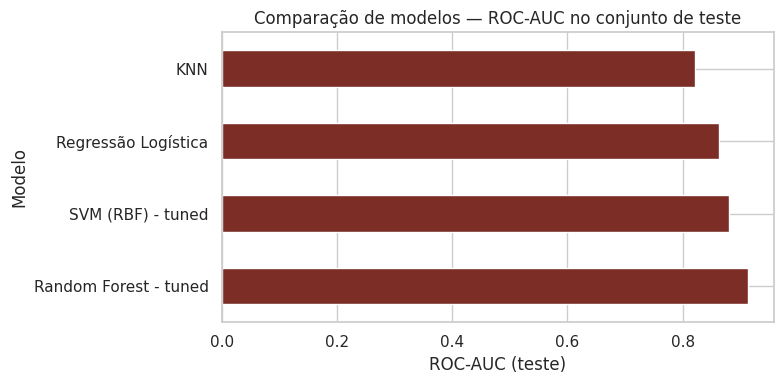

In [ ]:
test_results_df.sort_values('ROC-AUC', ascending=False)['ROC-AUC'].plot(
    kind='barh', color='#7B2D26', figsize=(8, 4))
plt.xlabel('ROC-AUC (teste)')
plt.title('Comparação de modelos — ROC-AUC no conjunto de teste')
plt.tight_layout()
plt.savefig('../results/05_comparacao_modelos_auc.png', dpi=150)
plt.show()


### 8.1 Classification Report detalhado

In [ ]:
for name, model in final_models.items():
    y_pred = model.predict(X_test)
    print(f'{"="*60}\n{name}\n{"="*60}')
    print(classification_report(y_test, y_pred, target_names=['Baixa/Média', 'Alta Qualidade']))


Regressão Logística
                precision    recall  f1-score   support

   Baixa/Média       0.94      0.81      0.87       197
Alta Qualidade       0.36      0.66      0.47        32

      accuracy                           0.79       229
     macro avg       0.65      0.73      0.67       229
  weighted avg       0.86      0.79      0.81       229

KNN
                precision    recall  f1-score   support

   Baixa/Média       0.92      0.97      0.94       197
Alta Qualidade       0.71      0.47      0.57        32

      accuracy                           0.90       229
     macro avg       0.82      0.72      0.75       229
  weighted avg       0.89      0.90      0.89       229

SVM (RBF) - tuned
                precision    recall  f1-score   support

   Baixa/Média       0.95      0.87      0.91       197
Alta Qualidade       0.48      0.72      0.57        32

      accuracy                           0.85       229
     macro avg       0.71      0.80      0.74       22

### 8.2 Matrizes de confusão

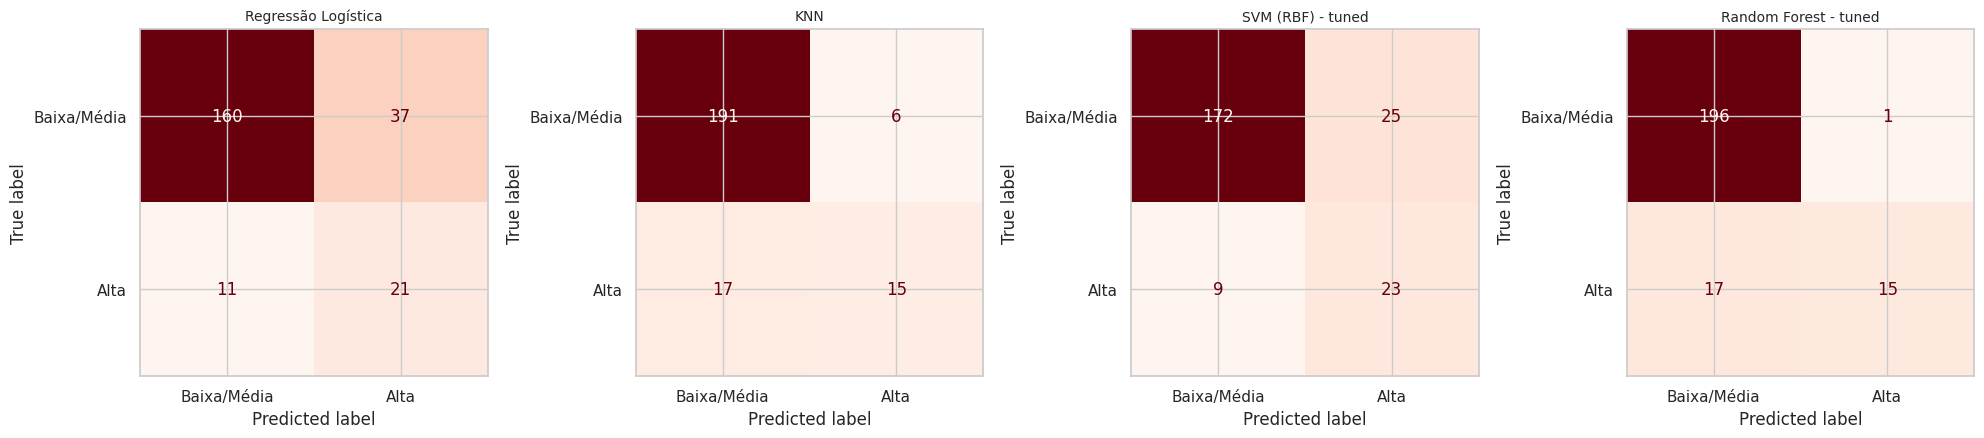

In [ ]:
fig, axes = plt.subplots(1, len(final_models), figsize=(5 * len(final_models), 4.5))

for ax, (name, model) in zip(axes, final_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Baixa/Média', 'Alta'])
    disp.plot(ax=ax, cmap='Reds', colorbar=False)
    ax.set_title(name, fontsize=10)

plt.tight_layout()
plt.savefig('../results/06_matrizes_confusao.png', dpi=150)
plt.show()


### 8.3 Curva ROC e AUC Score — comparação entre modelos

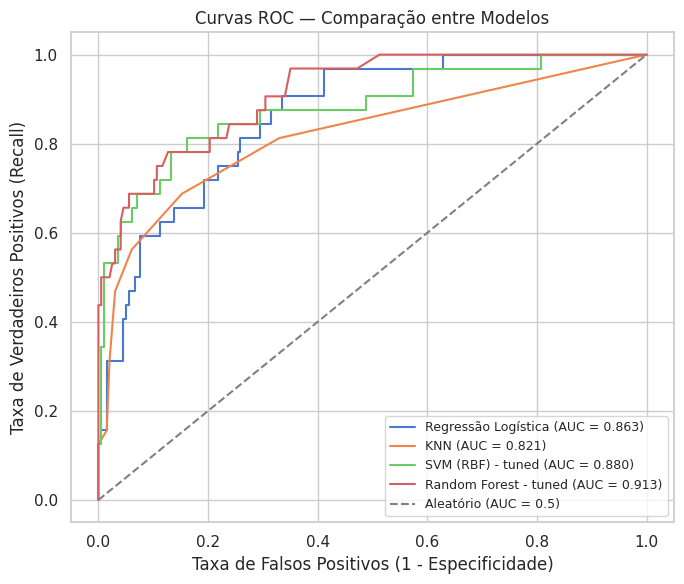

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))

for name, model in final_models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Aleatório (AUC = 0.5)')
ax.set_xlabel('Taxa de Falsos Positivos (1 - Especificidade)')
ax.set_ylabel('Taxa de Verdadeiros Positivos (Recall)')
ax.set_title('Curvas ROC — Comparação entre Modelos')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('../results/07_curvas_roc.png', dpi=150)
plt.show()


**Escolha do modelo final:** no conjunto de teste, o **Random Forest (tuned)** obteve o melhor resultado geral — maior Accuracy (0.921), Precision (0.938), F1-Score (0.625) e ROC-AUC (0.913) entre os quatro modelos. Isso indica que, quando o modelo prevê 'Alta Qualidade', ele erra pouco (alta precisão).

Existe, porém, um **trade-off relevante com o SVM**: o SVM (RBF) atinge o maior Recall (0.719 contra 0.469 do Random Forest), ou seja, identifica mais vinhos de alta qualidade de fato, ao custo de mais falsos positivos (Precision de apenas 0.479).

**Recomendação prática:** se o custo de negócio for **deixar passar um vinho bom sem identificar** (ex.: perder oportunidade de destacar um lote premium), o SVM é preferível. Se o custo maior for **classificar um vinho comum como premium por engano** (ex.: prometer qualidade que não será entregue ao cliente), o Random Forest é a escolha mais segura. Dado o cenário de triagem para apoiar — e não substituir — a avaliação sensorial humana, o **Random Forest** é recomendado como modelo principal, com a Regressão Logística como alternativa mais simples e interpretável para cenários que exijam explicabilidade regulatória.

## 9. Interpretação dos Resultados

### 9.1 Importância das variáveis (Random Forest)

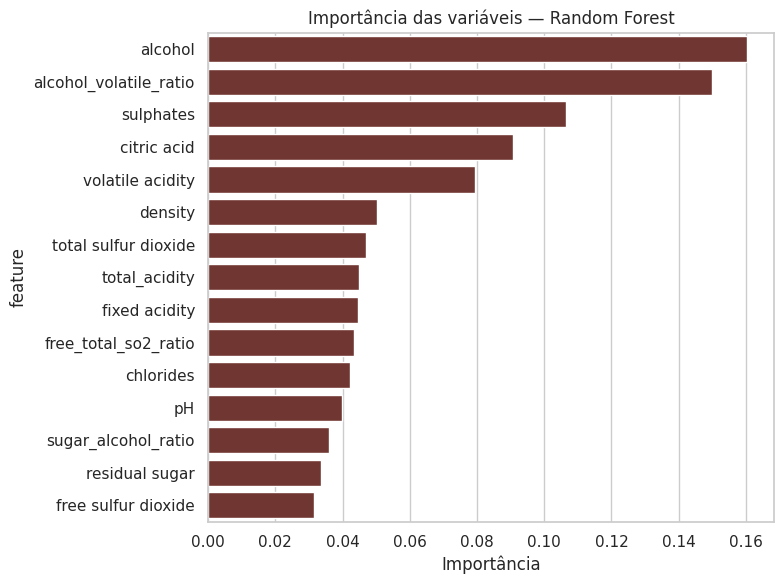

,feature,importance
10,alcohol,0.160347
13,alcohol_volatile_ratio,0.149826
9,sulphates,0.106380
2,citric acid,0.090742
1,volatile acidity,0.079529
7,density,0.050219
6,total sulfur dioxide,0.046948
12,total_acidity,0.045034
0,fixed acidity,0.044486
11,free_total_so2_ratio,0.043464


In [ ]:
rf_final = final_models['Random Forest - tuned']
importances = rf_final.named_steps['clf'].feature_importances_
feat_names = X.columns

importance_df = pd.DataFrame({'feature': feat_names, 'importance': importances}) \
    .sort_values('importance', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x='importance', y='feature', data=importance_df, color='#7B2D26')
plt.title('Importância das variáveis — Random Forest')
plt.xlabel('Importância')
plt.tight_layout()
plt.savefig('../results/08_importancia_variaveis.png', dpi=150)
plt.show()

importance_df


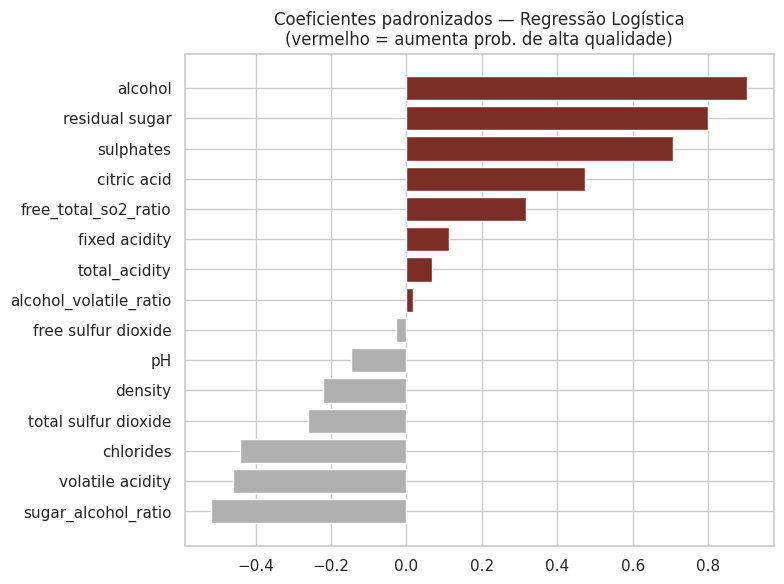

In [ ]:
# Coeficientes da Regressão Logística (direção do efeito, em escala padronizada)
log_reg = final_models['Regressão Logística'].named_steps['clf']
coef_df = pd.DataFrame({'feature': feat_names, 'coeficiente': log_reg.coef_[0]}) \
    .sort_values('coeficiente')

plt.figure(figsize=(8, 6))
colors = ['#B0B0B0' if c < 0 else '#7B2D26' for c in coef_df['coeficiente']]
plt.barh(coef_df['feature'], coef_df['coeficiente'], color=colors)
plt.title('Coeficientes padronizados — Regressão Logística\n(vermelho = aumenta prob. de alta qualidade)')
plt.tight_layout()
plt.savefig('../results/09_coeficientes_logistica.png', dpi=150)
plt.show()


**Principais variáveis que influenciam a qualidade do vinho:**

1. **`alcohol`** — a variável mais importante em ambos os modelos. Vinhos com maior teor alcoólico tendem fortemente a ser classificados como alta qualidade.
2. **`alcohol_volatile_ratio`** (feature criada) — confirma que a *combinação* de alto álcool com baixa acidez volátil é um forte indicador de qualidade, mais informativa que as variáveis isoladas.
3. **`sulphates`** — segundo fator mais relevante; níveis adequados de sulfatos (conservante) estão associados a vinhos melhor avaliados.
4. **`volatile acidity`** — relação negativa consistente: quanto maior a acidez volátil (defeito de acetificação/"vinagre"), menor a qualidade.
5. **`total sulfur dioxide`** — aparece com peso moderado, indicando papel no controle microbiológico/oxidativo do vinho.

### 9.2 Implicações para o processo de produção

- **Controle de maturação e fermentação:** como o teor alcoólico é o fator mais associado à alta qualidade, produtores podem monitorar o ponto de colheita da uva (nível de açúcar/Brix) e a eficiência da fermentação para atingir teores alcoólicos mais consistentes.
- **Controle de acidez volátil:** é a variável mais associada negativamente à qualidade — reforça a importância de boas práticas sanitárias na vinificação (evitar contaminação bacteriana que gera ácido acético).
- **Dosagem de sulfatos/SO2:** os resultados sugerem que existe uma faixa "ótima" de sulfatos e SO2 total — nem tão baixa (risco de oxidação/contaminação) nem tão alta (pode gerar notas sensoriais indesejadas). Vale a pena um estudo dedicado à faixa ideal.
- **Uso do modelo em produção:** o modelo pode ser incorporado como uma etapa de **triagem automática de lotes** antes da avaliação sensorial humana, priorizando a atenção dos enólogos para lotes "duvidosos" (probabilidade intermediária) e agilizando a aprovação de lotes com alta confiança de qualidade.


## 10. Conclusão

- Foi construído um pipeline completo de classificação binária para prever vinhos de alta qualidade a partir de variáveis físico-químicas.
- O dataset apresenta desbalanceamento de classes (~14% de alta qualidade), tratado via `class_weight='balanced'`, estratificação e uso de métricas adequadas (F1, Recall, ROC-AUC).
- Dentre os quatro modelos testados (Regressão Logística, KNN, SVM e Random Forest), o **Random Forest** apresentou o melhor desempenho geral no conjunto de teste.
- As variáveis físico-químicas mais determinantes da qualidade percebida são **teor alcoólico**, **acidez volátil** e **sulfatos** — achado consistente com o conhecimento enológico tradicional, o que reforça a validade do modelo.
- Próximos passos possíveis: testar modelos de boosting (XGBoost/LightGBM), coletar mais amostras da classe minoritária, e validar o modelo com dados de novas safras.
